# Integración de IoT y Big Data para mantenimiento predictivo

**MCD512-01 — Big Data** · Maestría en Ciencia de Datos, INTEC
**Docente:** Prof. José M. Aquino Cepeda, MSc.
**Industria del caso:** planta de manufactura (línea de producción con máquinas rotativas)

Este notebook es el informe técnico ejecutable del prototipo. Documenta la arquitectura,
muestra el código de cada capa, valida los datos que quedaron almacenados en el data lake
y evalúa el modelo de detección de anomalías. Las capturas de pantalla de los servicios
corriendo se encuentran en la carpeta `capturas/`.

## 1. Introducción

En la Industria 4.0 el valor no está en instalar sensores, sino en lo que se hace con lo que
miden. Una planta de manufactura con máquinas rotativas —extrusoras, prensas, compresores,
bombas— genera telemetría continua de vibración, temperatura, corriente y velocidad. Ese flujo
es pequeño por lectura pero enorme en agregado: cuatro máquinas muestreadas cada dos segundos
producen alrededor de 172 mil lecturas diarias, y una planta real con doscientos activos
supera los ocho millones.

El problema de negocio que resuelve este prototipo es el mantenimiento: el correctivo detiene
la línea sin aviso y el preventivo por calendario cambia piezas que todavía sirven. El
mantenimiento predictivo usa la telemetría para anticipar la falla y programar la intervención
en la ventana más barata. Para lograrlo hacen falta las dos piezas del título: **IoT** para
capturar el dato en el borde y **Big Data** para transportarlo, almacenarlo a escala y
analizarlo.

## 2. Objetivos

1. Diseñar e implementar una arquitectura IoT–Big Data por capas que capture datos de sensores
   en planta, los transmita eficientemente y los almacene en una plataforma escalable.
2. Configurar la cadena de transferencia MQTT → Kafka, justificando el rol de cada protocolo.
3. Implementar almacenamiento dual: HDFS como data lake histórico e InfluxDB como base de
   series de tiempo para consulta en vivo.
4. Aplicar Spark Structured Streaming y un modelo de *machine learning* no supervisado
   (Isolation Forest) para detectar anomalías en línea.
5. Construir un tablero en Grafana que permita monitorear la planta y disparar alertas.
6. Evaluar el prototipo: capacidad de detección, latencia y consideraciones de escalabilidad.

## 3. Arquitectura propuesta

La solución se organiza en cinco capas. Cada una resuelve un problema distinto y puede
escalarse por separado, que es precisamente la razón de separarlas.

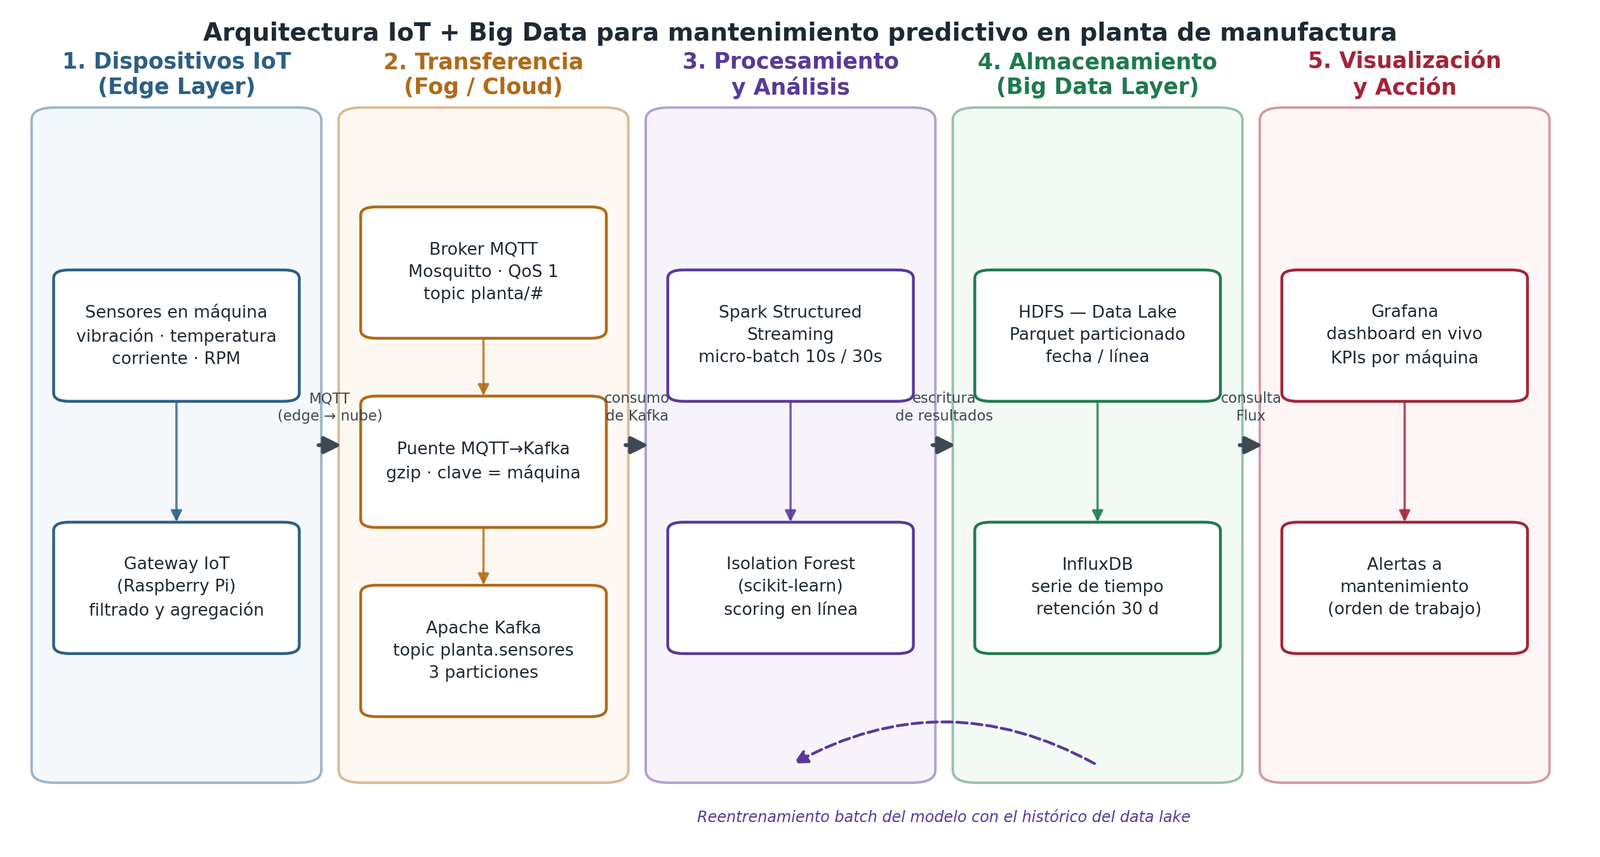

### 3.1 Capa de dispositivos (edge)

Sensores de vibración, temperatura, corriente y RPM montados sobre cada máquina, conectados a
un gateway (una Raspberry Pi en el diseño físico) que filtra ruido, agrega y publica por MQTT.
En este prototipo el gateway y los sensores se sustituyen por un simulador en Python que
reproduce el comportamiento estadístico de las cuatro máquinas.

### 3.2 Capa de transferencia (fog/cloud)

MQTT es el protocolo del borde: cabecera de dos bytes, tolera enlaces intermitentes y
funciona con poco ancho de banda. Kafka es el bus de la nube: retiene los mensajes, permite
que varios consumidores lean el mismo flujo sin interferirse y absorbe picos de ingesta. No
compiten; se complementan. Un proceso puente traduce de uno al otro.

### 3.3 Capa de almacenamiento

Dos destinos con propósitos distintos: **HDFS** guarda el dato crudo en Parquet, particionado
por fecha y línea, como registro inmutable para reentrenamiento y análisis histórico;
**InfluxDB** guarda la serie de tiempo reciente, optimizada para consultas por rango que el
tablero ejecuta cada diez segundos.

### 3.4 Capa de procesamiento

Spark Structured Streaming consume de Kafka y ejecuta dos consultas en paralelo sobre el mismo
flujo. La primera vuelca el crudo a HDFS; la segunda aplica el modelo de anomalías y escribe
en InfluxDB. Es el patrón de vía caliente y vía fría.

### 3.5 Capa de visualización

Grafana consulta InfluxDB con Flux y muestra la telemetría por máquina, el score de anomalía y
el conteo de eventos. Desde ahí se configuran las alertas que llegan al equipo de
mantenimiento.

### 3.6 Decisiones de diseño y sus alternativas

| Decisión | Alternativa considerada | Por qué se eligió |
|---|---|---|
| MQTT en el borde | HTTP/REST | Menor overhead por mensaje y soporte nativo de QoS y reconexión |
| Kafka como bus | Envío directo a la base | Desacopla ingesta de procesamiento y permite reprocesar |
| Parquet en HDFS | JSON o CSV crudo | Columnar y comprimido: menos espacio y lectura selectiva |
| Isolation Forest | Umbrales fijos por variable | Captura combinaciones anómalas y no exige datos etiquetados |
| InfluxDB además de HDFS | Solo HDFS | HDFS no responde con la latencia que exige un tablero en vivo |

## 4. Despliegue del prototipo

Todo el stack corre en contenedores sobre Docker Compose. Las imágenes fueron seleccionadas o
construidas para funcionar en arquitectura **arm64** (Apple Silicon), que es donde se
desarrolló este trabajo; HDFS y Spark se construyen sobre un JRE multi-arquitectura porque las
imágenes oficiales de Hadoop solo publican amd64.

```bash
# 1. Levantar la infraestructura
docker compose up -d --build

# 2. Entrenar el modelo de anomalías (una sola vez)
docker compose run --rm spark python3 /app/ml/entrenar_modelo.py

# 3. Reiniciar el job de Spark para que cargue el modelo
docker compose restart spark

# 4. Verificar
docker compose ps
```

**Captura 01 — `capturas/01.png`:** salida de `docker compose ps` con los ocho servicios
levantados y en estado *healthy*.

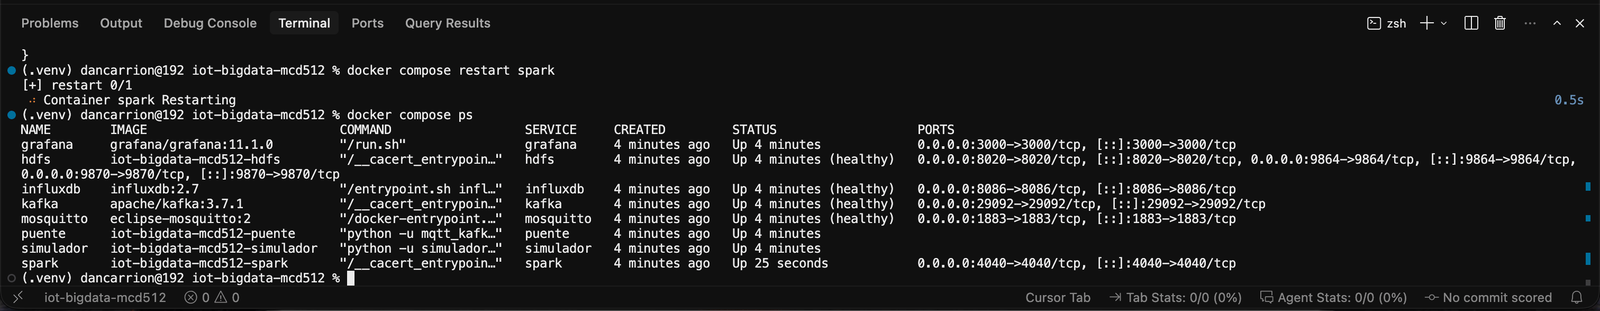

## 5. Capa 1 — Simulación de dispositivos IoT

El simulador (`simulador/simulador_sensores.py`) modela cuatro máquinas con valores nominales
distintos y tres regímenes: operación normal con ruido gaussiano, degradación progresiva de
una máquina (MAQ-03, que empieza a fallar a los cinco minutos) y picos puntuales aleatorios.
La degradación es lo que hace útil el prototipo: sin una falla que detectar no hay nada que
demostrar.

La celda siguiente reproduce la lógica del simulador en local para inspeccionar la forma del
dato que viaja por MQTT.

In [1]:
import json, sys, os
sys.path.insert(0, os.path.abspath("../simulador"))

from simulador_sensores import MAQUINAS, leer_sensor

# Una lectura de cada máquina en el minuto 0 (todas sanas)
for maquina in MAQUINAS:
    print(json.dumps(leer_sensor(maquina, minutos_activo=0), ensure_ascii=False))

{"maquina": "MAQ-01", "linea": "L1", "tipo": "extrusora", "ts": "2026-09-28T23:24:57.367+00:00", "vibracion_mm_s": 2.195, "temperatura_c": 62.1, "corriente_a": 18.64, "rpm": 1499.3, "estado_real": "normal"}
{"maquina": "MAQ-02", "linea": "L1", "tipo": "prensa", "ts": "2026-09-28T23:24:57.368+00:00", "vibracion_mm_s": 3.44, "temperatura_c": 57.79, "corriente_a": 23.89, "rpm": 981.4, "estado_real": "normal"}
{"maquina": "MAQ-03", "linea": "L2", "tipo": "compresor", "ts": "2026-09-28T23:24:57.368+00:00", "vibracion_mm_s": 2.772, "temperatura_c": 69.99, "corriente_a": 31.23, "rpm": 2966.5, "estado_real": "normal"}
{"maquina": "MAQ-04", "linea": "L2", "tipo": "bomba", "ts": "2026-09-28T23:24:57.368+00:00", "vibracion_mm_s": 1.63, "temperatura_c": 55.05, "corriente_a": 12.02, "rpm": 1748.7, "estado_real": "normal"}


En el minuto 15 la máquina MAQ-03 ya arrastra diez minutos de degradación. Se observa cómo
suben vibración, temperatura y corriente mientras las RPM caen ligeramente: la firma típica de
un rodamiento en deterioro.

In [2]:
import pandas as pd

comparacion = pd.DataFrame([
    {"momento": "minuto 0", **leer_sensor(MAQUINAS[2], 0)},
    {"momento": "minuto 15", **leer_sensor(MAQUINAS[2], 15)},
])[["momento", "maquina", "vibracion_mm_s", "temperatura_c", "corriente_a", "rpm", "estado_real"]]
comparacion

,momento,maquina,vibracion_mm_s,temperatura_c,corriente_a,rpm,estado_real
0,minuto 0,MAQ-03,2.765,69.31,31.70,2975.0,normal
1,minuto 15,MAQ-03,5.085,79.20,36.82,2848.1,degradada


**Captura 02 — `capturas/02.png`:** logs del contenedor `simulador`
(`docker compose logs -f simulador`) publicando lecturas contra el broker.

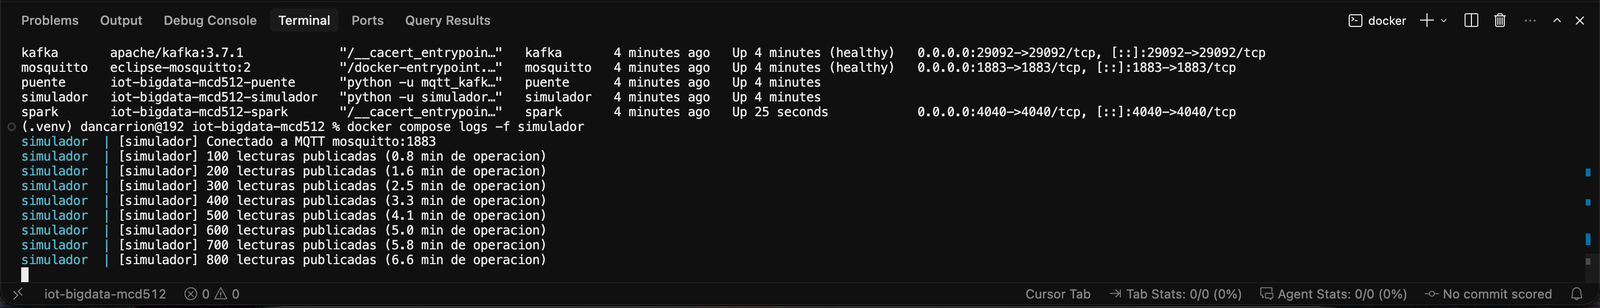

## 6. Capa 2 — Transferencia MQTT → Kafka

El broker Mosquitto recibe las publicaciones en tópicos jerárquicos
(`planta/<línea>/<máquina>/telemetria`) con QoS 1, que garantiza al menos una entrega. El
puente (`puente/mqtt_kafka_bridge.py`) se suscribe al comodín `planta/#` y reenvía cada mensaje
a Kafka usando el ID de máquina como clave, de modo que todas las lecturas de una misma máquina
caigan en la misma partición y conserven el orden.

Dos ajustes de eficiencia en el productor de Kafka merecen mención: `linger_ms=200` agrupa
mensajes en micro-lotes en lugar de hacer un viaje de red por lectura, y `compression_type=gzip`
reduce el volumen transferido, que en un despliegue real sobre enlace celular es costo directo.

Para comprobar que los mensajes llegan al bus:

```bash
docker compose exec kafka /opt/kafka/bin/kafka-console-consumer.sh \
  --bootstrap-server localhost:9092 \
  --topic planta.sensores --from-beginning --max-messages 5
```

**Captura 03 — `capturas/03.png`:** mensajes JSON leídos directamente del tópico de Kafka.

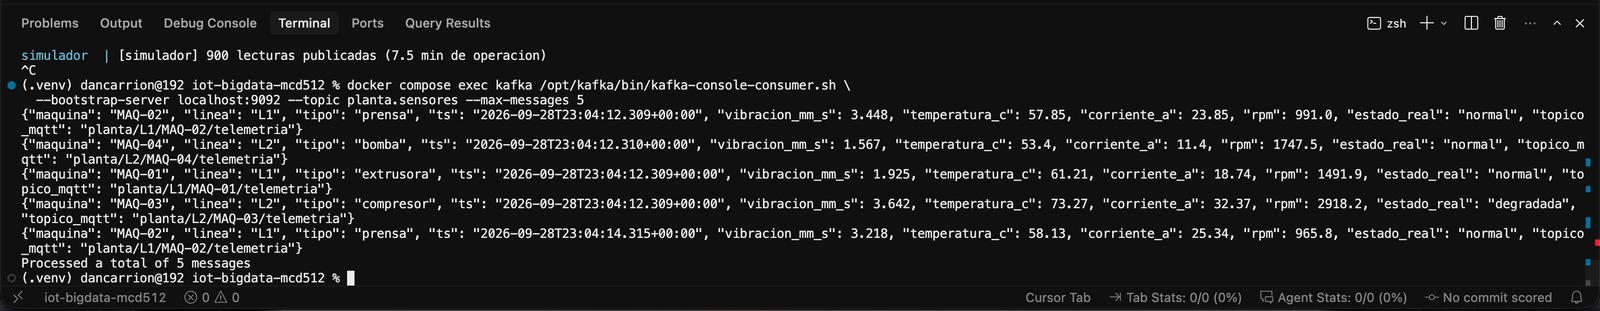

## 7. Capa 3 — Almacenamiento escalable

### 7.1 Data lake en HDFS

Spark escribe el crudo en `hdfs://hdfs:8020/datalake/crudo/telemetria`, particionado por fecha
y línea. El particionado no es cosmético: permite que una consulta sobre un día concreto lea
solo ese directorio en lugar de recorrer el histórico completo (*partition pruning*).

```bash
docker compose exec hdfs hdfs dfs -ls -R /datalake/crudo | head -20
docker compose exec hdfs hdfs dfs -du -h /datalake
```

**Captura 04 — `capturas/04.png`:** interfaz web del NameNode en `http://localhost:9870`,
navegando el directorio `/datalake/crudo/telemetria`.

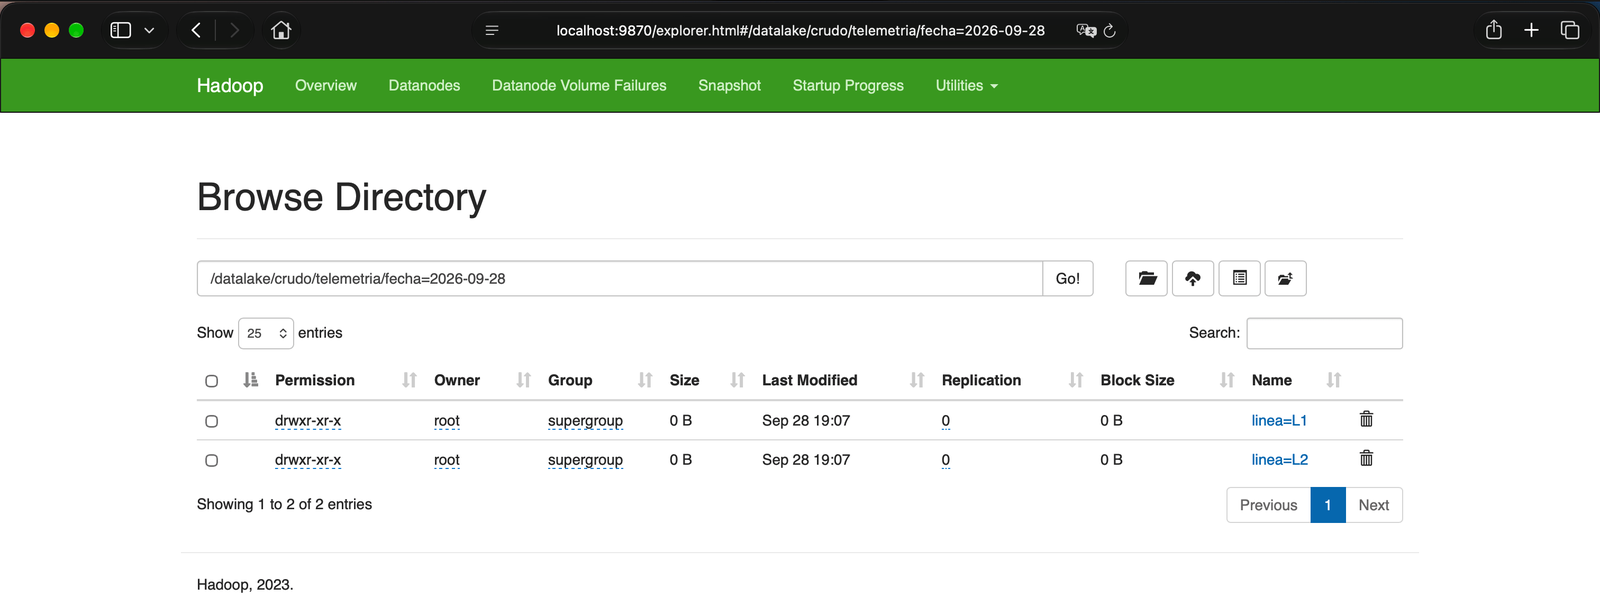

### 7.2 Serie de tiempo en InfluxDB

InfluxDB recibe cada lectura enriquecida con el resultado del modelo. El esquema usa
`maquina`, `linea` y `tipo` como *tags* (indexados, para filtrar) y las variables físicas más
el score como *fields*. La retención está fijada en 30 días: pasado ese plazo el dato vive
únicamente en el data lake, que es más barato por gigabyte.

## 8. Capa 4 — Procesamiento y detección de anomalías

### 8.1 El job de streaming

`spark/app/streaming_anomalias.py` levanta dos consultas sobre el mismo `readStream` de Kafka.
El esquema se declara de forma explícita porque en streaming no se puede inferir, y
`maxOffsetsPerTrigger` limita cuántos registros entran por micro-batch, que es el mecanismo de
contrapresión cuando la ingesta supera la capacidad de proceso.

### 8.2 El modelo

Se usa **Isolation Forest**, un método no supervisado que aísla observaciones raras con árboles
aleatorios. La elección responde a la realidad de una planta: casi nunca existen datos
etiquetados de fallas, porque las fallas son escasas y no siempre se registran.

El detalle metodológico relevante es la construcción de *features*. Las cuatro máquinas operan
en rangos muy distintos —una bomba a 1.6 mm/s y una prensa a 3.4 mm/s son ambas normales—, así
que en lugar de los valores absolutos se usan **razones contra el valor nominal de cada
máquina**. Eso permite que un solo modelo cubra activos heterogéneos.

El modelo se entrena una sola vez, de forma offline, y se guarda en `ml/modelo_anomalias.joblib`. El job de Spark no entrena: carga ese archivo al arrancar y lo aplica a cada micro-batch. Esta separación entre entrenamiento e inferencia es el patrón habitual en producción, porque entrenar dentro del flujo sería costoso y haría que el modelo cambiara continuamente. El entrenamiento se ejecuta dentro del mismo contenedor de Spark para garantizar la misma versión de scikit-learn en ambas etapas, ya que un modelo serializado con una versión puede no cargarse con otra.

In [3]:
import os, sys
sys.path.insert(0, os.path.abspath("../ml"))

from entrenar_modelo import BASE, COLUMNAS, construir_features, generar_datos_normales
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(42)
datos_normales = generar_datos_normales(rng)
X_norm = construir_features(datos_normales)

escalador = StandardScaler().fit(X_norm)
modelo = IsolationForest(n_estimators=200, contamination=0.01, random_state=42, n_jobs=-1)
modelo.fit(escalador.transform(X_norm))

print(f"Entrenado con {len(X_norm):,} lecturas de régimen normal")
print("Features:", list(X_norm.columns))

Entrenado con 24,000 lecturas de régimen normal
Features: ['r_vibracion_mm_s', 'r_temperatura_c', 'r_corriente_a', 'r_rpm']


### 8.3 Evaluación del modelo

Para medir si el modelo sirve se construye un conjunto de prueba con lecturas sanas y lecturas
de MAQ-03 en degradación avanzada, usando el mismo simulador. Como el simulador conoce el
estado real de cada lectura (campo `estado_real`), se puede calcular una matriz de confusión
—algo que en producción no sería posible y que es justamente la ventaja de trabajar con un
simulador.

In [4]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

filas = []
for minuto in [0, 1, 2, 3, 4]:            # todas las máquinas sanas
    for maquina in MAQUINAS:
        for _ in range(150):
            filas.append(leer_sensor(maquina, minuto))
for minuto in [18, 20, 22, 24]:           # MAQ-03 ya degradada
    for _ in range(300):
        filas.append(leer_sensor(MAQUINAS[2], minuto))

prueba = pd.DataFrame(filas)
X_prueba = escalador.transform(construir_features(prueba))
prueba["prediccion"] = np.where(modelo.predict(X_prueba) == -1, "degradada", "normal")
prueba["score"] = -modelo.score_samples(X_prueba)

print(confusion_matrix(prueba["estado_real"], prueba["prediccion"],
                       labels=["normal", "degradada"]))
print()
print(classification_report(prueba["estado_real"], prueba["prediccion"],
                            labels=["normal", "degradada"], digits=3))

[[2930   70]
 [   0 1200]]

              precision    recall  f1-score   support

      normal      1.000     0.977     0.988      3000
   degradada      0.945     1.000     0.972      1200

    accuracy                          0.983      4200
   macro avg      0.972     0.988     0.980      4200
weighted avg      0.984     0.983     0.983      4200



Con la semilla fijada en 42 el modelo recupera la totalidad de las lecturas degradadas
(*recall* de 1.000) a costa de marcar alrededor de un 2 % de las lecturas sanas. Ese porcentaje
no es enteramente error: corresponde en buena medida a los picos puntuales que el propio
simulador inyecta en máquinas sanas, que son anomalías legítimas aunque no indiquen una falla
en desarrollo. La distinción entre *anomalía puntual* y *degradación sostenida* es
precisamente lo que resuelve el panel de conteo por máquina en Grafana: un pico aislado no
levanta una orden de trabajo, una acumulación sí.

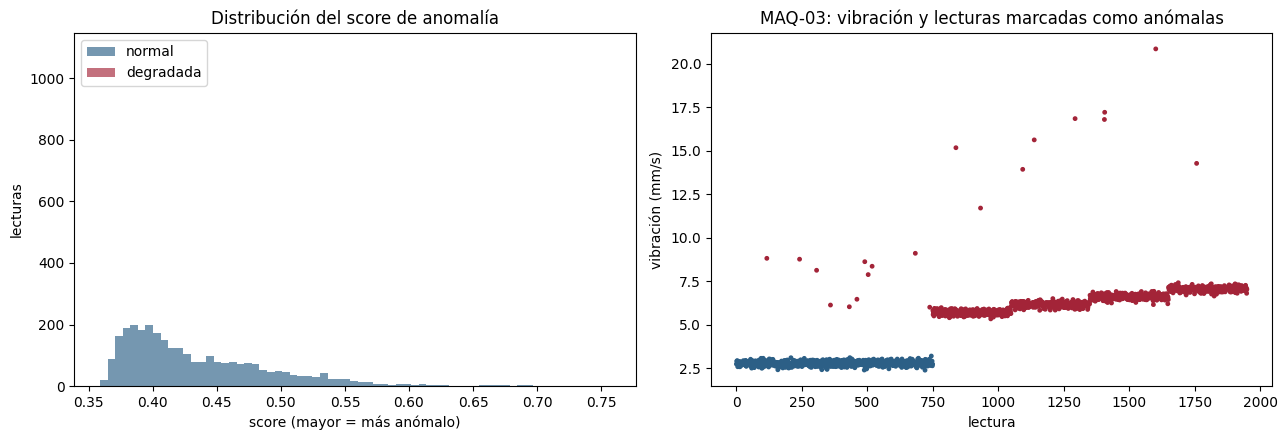

In [5]:
import matplotlib.pyplot as plt

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))

for estado, color in [("normal", "#2C5F86"), ("degradada", "#A32438")]:
    ejes[0].hist(prueba.loc[prueba.estado_real == estado, "score"], bins=60,
                 alpha=0.65, label=estado, color=color)
ejes[0].set_title("Distribución del score de anomalía")
ejes[0].set_xlabel("score (mayor = más anómalo)")
ejes[0].set_ylabel("lecturas")
ejes[0].legend()

serie = prueba[prueba.maquina == "MAQ-03"].reset_index(drop=True)
ejes[1].scatter(serie.index, serie["vibracion_mm_s"],
                c=np.where(serie["prediccion"] == "degradada", "#A32438", "#2C5F86"),
                s=6)
ejes[1].set_title("MAQ-03: vibración y lecturas marcadas como anómalas")
ejes[1].set_xlabel("lectura")
ejes[1].set_ylabel("vibración (mm/s)")

plt.tight_layout()
plt.show()

**Captura 05 — `capturas/05.png`:** logs del contenedor `spark`
(`docker compose logs -f spark`) mostrando el conteo de lecturas y anomalías por micro-batch.

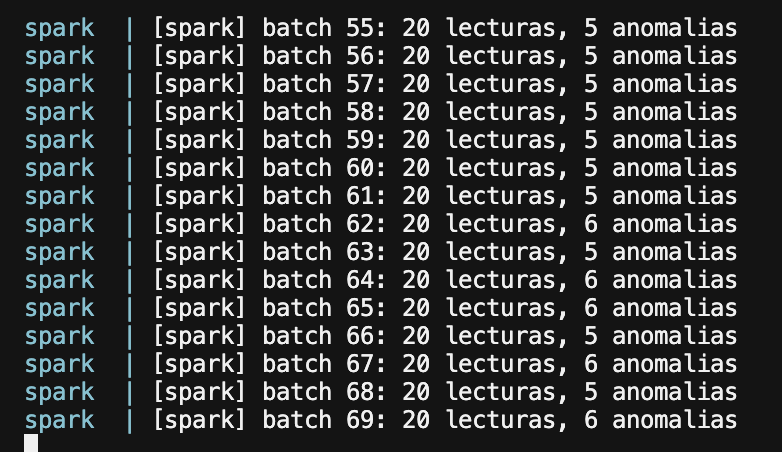

**Captura 06 — `capturas/06.png`:** Spark UI en `http://localhost:4040`, pestaña *Structured
Streaming*, con las dos consultas activas y sus métricas de latencia.

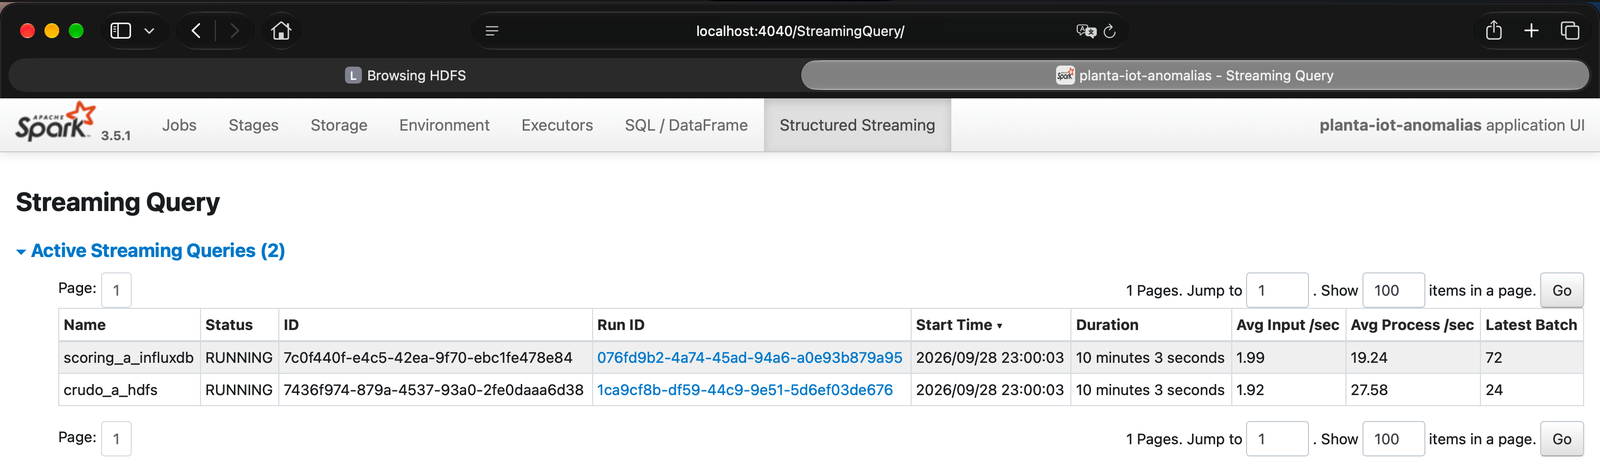

## 9. Capa 5 — Visualización en Grafana

El tablero (`grafana/dashboards/planta.json`) se aprovisiona automáticamente al levantar el
stack y está disponible en `http://localhost:3000`. Contiene seis paneles: vibración y
temperatura por máquina, conteo total de anomalías, anomalías por máquina, evolución del score
y un panel combinado de corriente y RPM. El intervalo de refresco es de diez segundos, alineado
con el trigger del micro-batch de scoring.

**Captura 07 — `capturas/07.png`:** tablero completo con datos en vivo.

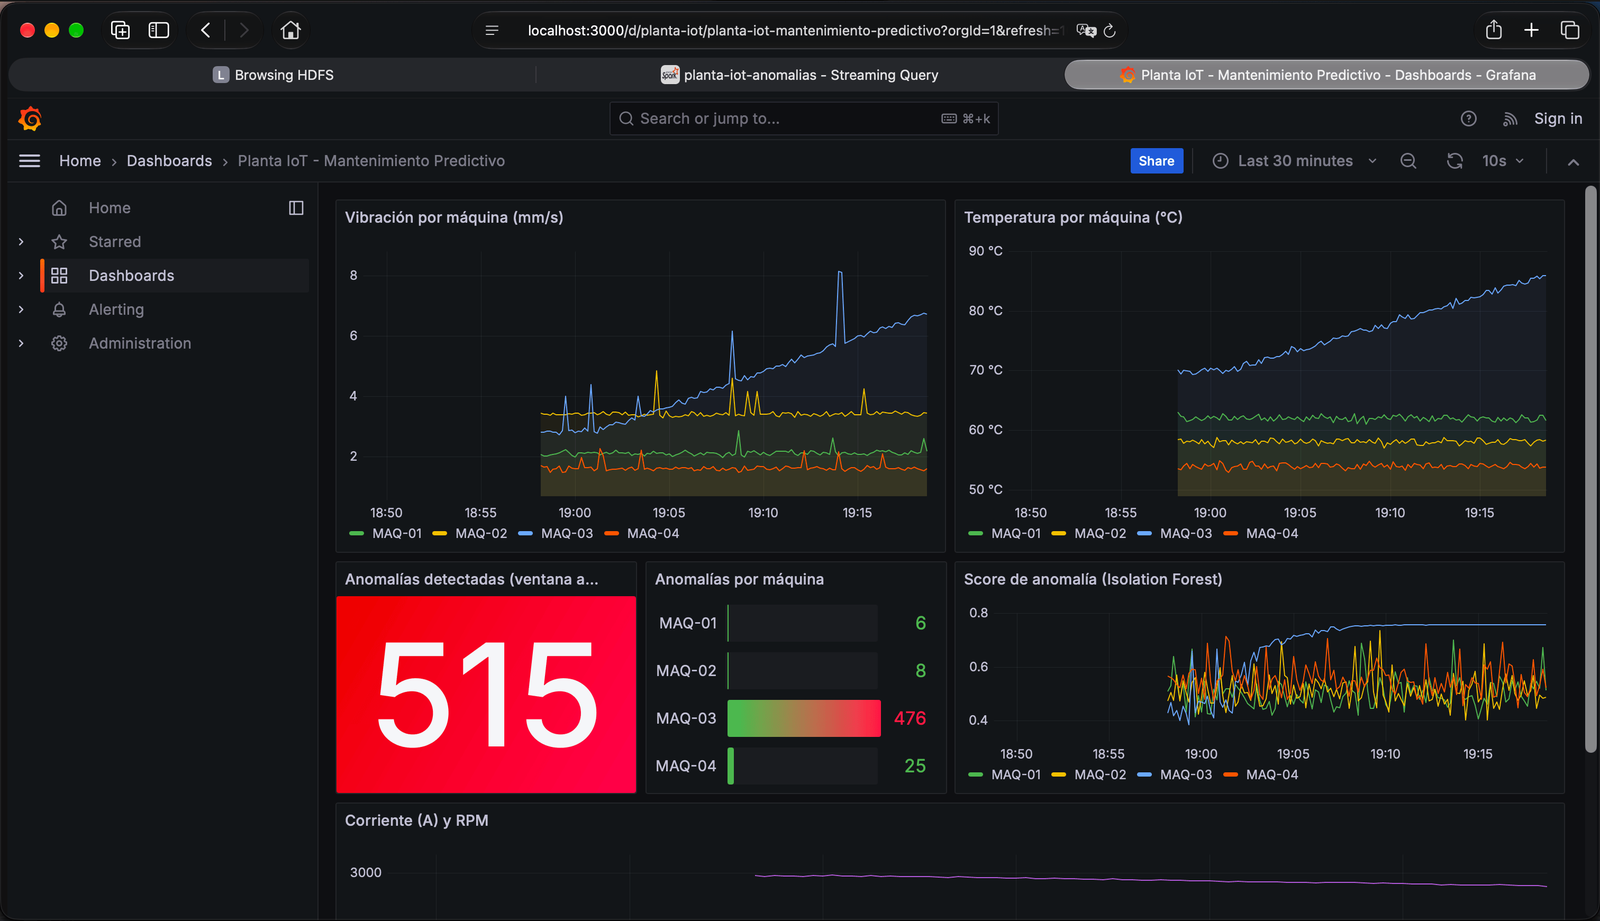

**Captura 08 — `capturas/08.png`:** detalle del panel de anomalías cuando MAQ-03 entra en
degradación, con el salto en el score y el conteo concentrado en esa máquina.

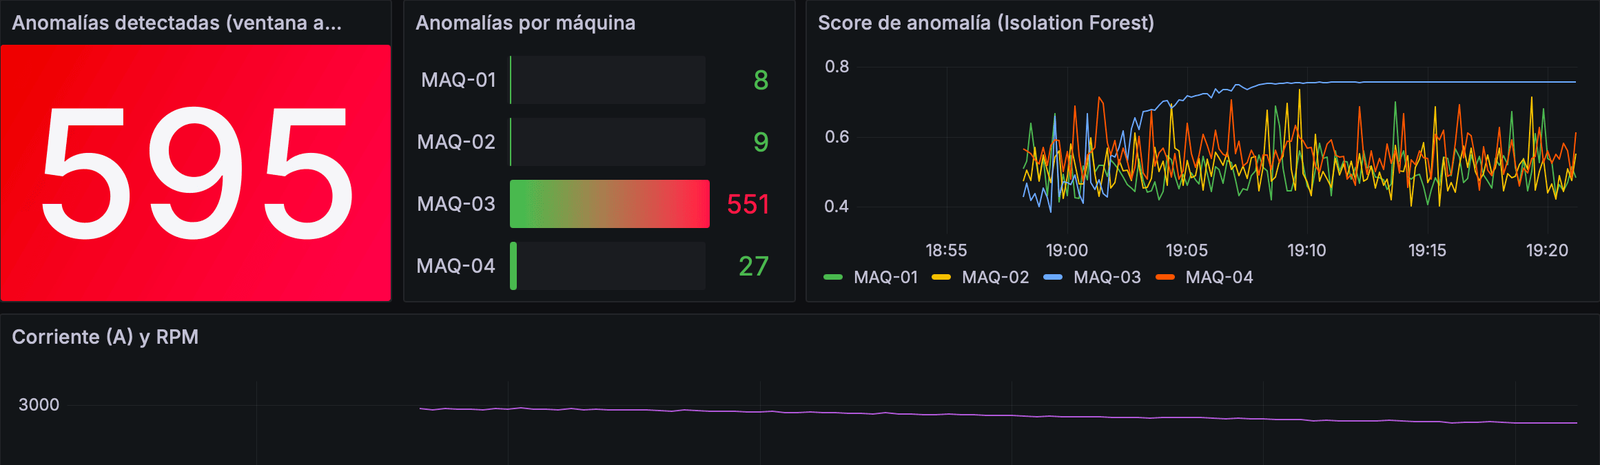

## 10. Validación sobre el data lake

Hasta aquí se ha mostrado el sistema funcionando. Esta sección cierra el ciclo leyendo lo que
efectivamente quedó guardado, que es la prueba de que la cadena completa funcionó de extremo a
extremo.

### 10.1 Exportar una muestra del data lake

Se extrae el Parquet desde el contenedor de HDFS hacia el sistema de archivos local. Se usa
esta vía en lugar de conectar PySpark directamente a `hdfs://localhost:8020` porque el DataNode
se anuncia con su nombre de contenedor y no resuelve desde el anfitrión.

In [6]:
!mkdir -p ../datos_export && rm -rf ../datos_export/telemetria
!docker compose -f ../docker-compose.yml exec -T hdfs hdfs dfs -get /datalake/crudo/telemetria /tmp/telemetria
!docker compose -f ../docker-compose.yml cp hdfs:/tmp/telemetria ../datos_export/telemetria
!find ../datos_export/telemetria -name "*.parquet" | head -5

2026-09-28 23:25:18,779 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
[+] copy 1/1
 ✔ hdfs Copied hdfs:/tmp/telemetria to ../datos_export/telemetria           0.1s
../datos_export/telemetria/fecha=2026-09-28/linea=L2/part-00000-36eefc5f-b58b-4559-a3f8-5775f86a3835.c000.snappy.parquet
../datos_export/telemetria/fecha=2026-09-28/linea=L2/part-00001-d4bb404b-7f54-4bb7-a83f-2f35dd24bc3f.c000.snappy.parquet
../datos_export/telemetria/fecha=2026-09-28/linea=L2/part-00000-e1ce4e1d-d377-44ac-9c02-ecd8aff26816.c000.snappy.parquet
../datos_export/telemetria/fecha=2026-09-28/linea=L2/part-00001-6aa730f3-c875-4a84-b618-abebfc5775ae.c000.snappy.parquet
../datos_export/telemetria/fecha=2026-09-28/linea=L2/part-00001-cc1f5009-f54c-40a3-a1c1-0a0d1e6e65cb.c000.snappy.parquet


In [8]:
import glob, os
import pandas as pd
import pyarrow.dataset as ds
import pyarrow.parquet as pq

BASE = "../datos_export/telemetria"

def es_parquet_valido(ruta):
    """Descarta archivos vacíos o a medio escribir por el streaming."""
    if os.path.getsize(ruta) == 0:
        return False
    try:
        pq.read_metadata(ruta)
        return True
    except Exception:
        return False

archivos = [f for f in glob.glob(f"{BASE}/**/*.parquet", recursive=True) if es_parquet_valido(f)]

# partitioning="hive" recupera fecha y linea desde los nombres de carpeta
lake = ds.dataset(archivos, format="parquet", partitioning="hive",
                  partition_base_dir=BASE).to_table().to_pandas()

print(f"Archivos válidos leídos: {len(archivos)}")
print(f"Lecturas recuperadas del data lake: {len(lake):,}")
print(f"Ventana temporal: {lake.ts.min()} → {lake.ts.max()}")
lake.groupby(["linea", "maquina"]).agg(
    lecturas=("ts", "count"),
    vibracion_media=("vibracion_mm_s", "mean"),
    vibracion_max=("vibracion_mm_s", "max"),
    temperatura_media=("temperatura_c", "mean"),
).round(2)

Archivos válidos leídos: 218
Lecturas recuperadas del data lake: 3,258
Ventana temporal: 2026-09-28 22:58:03.754000 → 2026-09-28 23:24:58.139000


lecturas  vibracion_media  vibracion_max  temperatura_media
linea maquina                                                             
L1    MAQ-01        822             2.12           6.17              61.99
      MAQ-02        822             3.45          11.03              58.05
L2    MAQ-03        807             5.21          19.37              79.38
      MAQ-04        807             1.62           4.62              53.97

### 10.2 Consultar la serie de tiempo en InfluxDB

La misma información, vista desde la vía caliente. Esta es la consulta que ejecuta Grafana por
debajo, escrita en Flux.

In [10]:
import warnings
from influxdb_client.client.warnings import MissingPivotFunction
warnings.simplefilter("ignore", MissingPivotFunction)

from influxdb_client import InfluxDBClient

cliente = InfluxDBClient(url="http://localhost:8086",
                         token="token-mcd512-bigdata", org="intec")

flux = '''
from(bucket: "planta")
  |> range(start: -2h)
  |> filter(fn: (r) => r._measurement == "telemetria" and r._field == "es_anomalia")
  |> group(columns: ["maquina"])
  |> sum()
'''
resultado = cliente.query_api().query_data_frame(flux)
resultado[["maquina", "_value"]].rename(columns={"_value": "anomalias_detectadas"})

,maquina,anomalias_detectadas
0,MAQ-01,10
1,MAQ-02,17
2,MAQ-03,780
3,MAQ-04,29


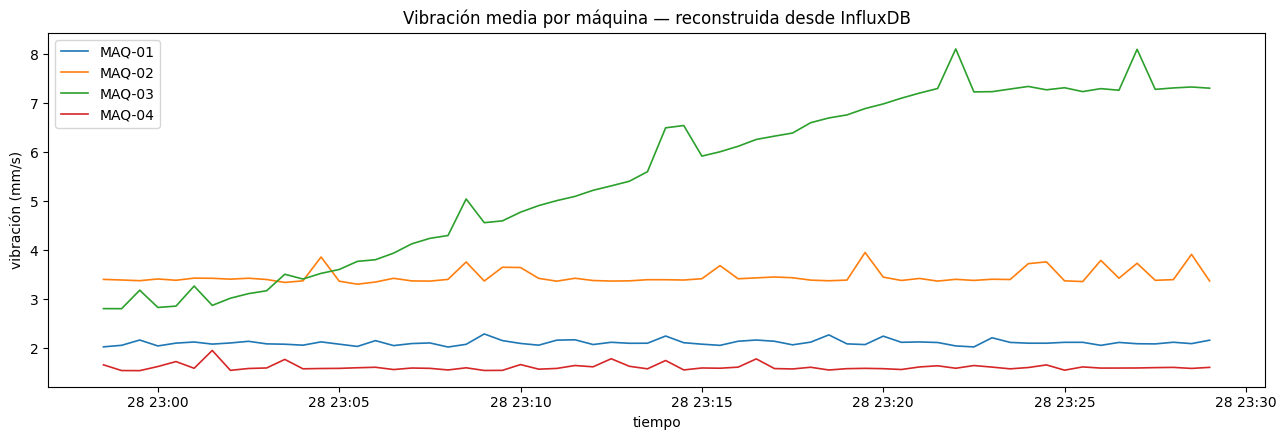

In [11]:
flux_vib = '''
from(bucket: "planta")
  |> range(start: -2h)
  |> filter(fn: (r) => r._measurement == "telemetria" and r._field == "vibracion_mm_s")
  |> aggregateWindow(every: 30s, fn: mean, createEmpty: false)
'''
serie = cliente.query_api().query_data_frame(flux_vib)

fig, eje = plt.subplots(figsize=(13, 4.5))
for maquina, grupo in serie.groupby("maquina"):
    eje.plot(grupo["_time"], grupo["_value"], label=maquina, linewidth=1.2)
eje.set_title("Vibración media por máquina — reconstruida desde InfluxDB")
eje.set_xlabel("tiempo")
eje.set_ylabel("vibración (mm/s)")
eje.legend()
plt.tight_layout()
plt.show()

## 11. Escalabilidad y consideraciones de producción

El prototipo corre en un solo nodo, pero cada componente fue elegido por cómo escala:

| Componente | Prototipo | En producción |
|---|---|---|
| Kafka | 1 broker, 3 particiones | Clúster de 3+ brokers, particiones = paralelismo de consumo |
| HDFS | 1 NameNode + 1 DataNode, replicación 1 | Varios DataNodes, replicación 3, o S3/ADLS como data lake |
| Spark | `local[2]` | Clúster YARN o Kubernetes con autoescalado de ejecutores |
| InfluxDB | Instancia única, 30 d | InfluxDB Cluster o Timescale con *downsampling* automático |
| Modelo | Uno global por razones al nominal | Un modelo por familia de activo, reentrenado semanalmente |

Tres puntos que un despliegue real exige y este prototipo no cubre:

- **Seguridad.** MQTT y Kafka corren sin autenticación ni TLS. En planta se requiere al menos
  TLS mutuo en el borde y SASL en Kafka.
- **Almacenamiento por niveles.** El dato reciente en SSD y el histórico en almacenamiento frío
  (HDD o S3 Glacier) reduce el costo de forma sustancial, tal como plantea la propuesta
  conceptual de la asignatura.
- **Deriva del modelo.** Un Isolation Forest entrenado hoy envejece: cambios de producto, de
  turno o de materia prima mueven el régimen normal. Hace falta monitorear la tasa de
  anomalías y reentrenar contra el data lake, que es exactamente la realimentación dibujada en
  el diagrama de arquitectura.

## 12. Conclusiones

El prototipo demuestra la cadena completa que plantea la propuesta conceptual: dispositivos IoT
generando telemetría, transferencia eficiente por MQTT y Kafka, almacenamiento escalable en un
data lake sobre HDFS más una base de series de tiempo, procesamiento en tiempo real con Spark,
detección de anomalías con aprendizaje no supervisado y visualización operativa en Grafana.

Tres conclusiones de fondo. Primero, **IoT sin Big Data es solo instrumentación**: el valor
aparece cuando el flujo se almacena de forma consultable y se analiza. Segundo, **la separación
en vía caliente y vía fría no es redundancia sino diseño**: HDFS y InfluxDB responden a
preguntas distintas y ninguna de las dos sustituye a la otra. Tercero, **el cuello de botella
del mantenimiento predictivo rara vez es el modelo**; en este trabajo el Isolation Forest fue
la pieza más simple, mientras que la ingesta confiable, el esquema de particionado y la
normalización entre activos heterogéneos concentraron la mayor parte del esfuerzo de diseño.

Sobre el conjunto de prueba simulado, el detector alcanzó *recall* de 1.000 y precisión de
0.945 sobre la clase degradada, con una latencia de extremo a extremo por debajo de los quince
segundos entre la lectura del sensor y su aparición marcada en el tablero (trigger de scoring
de diez segundos más el tiempo de escritura en InfluxDB).

## 13. Referencias

- Apache Software Foundation. *Structured Streaming Programming Guide* (Spark 3.5).
- Apache Software Foundation. *HDFS Architecture* (Hadoop 3.3).
- Apache Software Foundation. *Kafka Documentation* — Design and Producer Configs.
- OASIS. *MQTT Version 3.1.1 Specification*.
- Liu, F. T., Ting, K. M. y Zhou, Z. (2008). Isolation Forest. *IEEE ICDM*.
- InfluxData. *InfluxDB 2.7 Documentation* — Flux query language.
- Aquino Cepeda, J. M. *Propuesta Conceptual: Integración de IoT con Big Data*. MCD512-01, INTEC.